In [1]:

import numpy as np
import matplotlib.pyplot as plt

In [2]:
from tqdm.notebook import tqdm

In [3]:
import torch
import torch.nn as nn
import torch.nn.functional as F

In [4]:
# check if cuda is available
if torch.cuda.is_available():
    device = "cuda"
else:
    device = "cpu"

# Use dataset/dataloader to access data

In [5]:
import torchvision.datasets as datasets
from torchvision.transforms import v2

In [6]:
mnist_train = datasets.MNIST(root="./datasets", train=True, download=True)
mnist_test = datasets.MNIST(root="./datasets", train=False, download=True)

100%|██████████| 9.91M/9.91M [00:00<00:00, 15.4MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 472kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 3.82MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 6.79MB/s]


In [7]:
type(mnist_train[0][0])

PIL.Image.Image

In [8]:
# Slow! Creates an image from every record
# Better create TensorDataset
mnist_train_t = torch.utils.data.TensorDataset(mnist_train.data.reshape(-1,1,28,28).float()/255, mnist_train.targets)
mnist_test_t = torch.utils.data.TensorDataset(mnist_test.data.reshape(-1,1,28,28).float()/255, mnist_test.targets)

In [9]:
# DataLoaders
from torch.utils.data import DataLoader

In [10]:
dl_train = DataLoader(mnist_train_t, batch_size=128, shuffle=True)
dl_test = DataLoader(mnist_test_t, batch_size=128, shuffle=False)

In [12]:
# basic training loop with DataLoaders

In [11]:
# function to evaluate accuracy
def eval_net(net, d):
    net.eval()
    loss = torch.nn.CrossEntropyLoss(reduction="sum")
    with torch.no_grad():
        acc_sum = 0
        loss_sum = 0
        n = 0
        for x, y in d:
            y=y.to(device)
            x=x.to(device)
            pred = net(x)
            predicted = pred.argmax(axis=-1)
            acc_sum += (predicted==y).sum().item()
            loss_sum += loss(pred, y).item()
            n += x.shape[0]
    return acc_sum/n, loss_sum/n

In [12]:
def fit(net, train=dl_train, valid=dl_test, epochs=20):
    net = net.to(device)

    optimizer = torch.optim.Adam(net.parameters())

    loss = torch.nn.CrossEntropyLoss()
    for e in range(epochs):
        net.train()
        for X, y in tqdm(train):
            optimizer.zero_grad()
            X = X.to(device)
            y = y.to(device)
            pred = net(X)
            l = loss(pred, y)
            l.backward()
            optimizer.step()
        if valid is not None:
            print("Accuracy at epoch", e, ":", eval_net(net, valid)[0])

In [13]:
# simple network
m = nn.Sequential(nn.Conv2d(1, 32, 3), nn.ReLU(),
                  nn.Conv2d(32, 32, 3), nn.ReLU(),
                  nn.Flatten(),
                  nn.Linear(32*24*24, 10),
)
fit(m)

  0%|          | 0/469 [00:00<?, ?it/s]

Accuracy at epoch 0 : 0.9773


  0%|          | 0/469 [00:00<?, ?it/s]

Accuracy at epoch 1 : 0.9851


  0%|          | 0/469 [00:00<?, ?it/s]

...

Accuracy at epoch 17 : 0.9837


  0%|          | 0/469 [00:00<?, ?it/s]

Accuracy at epoch 18 : 0.9848


  0%|          | 0/469 [00:00<?, ?it/s]

Accuracy at epoch 19 : 0.9862


In [14]:
# keep history for plotting
def fit(net, train=dl_train, valid=dl_test, epochs=20):
    net = net.to(device)

    optimizer = torch.optim.Adam(net.parameters())

    loss = torch.nn.CrossEntropyLoss()
    hist_loss_train = []
    hist_loss_valid = []
    hist_acc_train = []
    hist_acc_valid = []

    for e in range(epochs):
        net.train()
        for X, y in tqdm(train):
            optimizer.zero_grad()
            X = X.to(device)
            y = y.to(device)
            pred = net(X)
            l = loss(pred, y)
            l.backward()
            optimizer.step()
        acc_train, loss_train = eval_net(net, train)
        hist_loss_train.append(loss_train)
        hist_acc_train.append(acc_train)
        if valid is not None:
            acc_valid, loss_valid = eval_net(net, valid)
            hist_loss_valid.append(loss_valid)
            hist_acc_valid.append(acc_valid)
            print("Accuracy/loss at epoch", e, ":", acc_valid, loss_valid)
    ret = {"loss": hist_loss_train, "accuracy": hist_acc_train}
    if valid is not None:
        ret["val_loss"] = hist_loss_valid
        ret["val_accuracy"] = hist_acc_valid
    return ret

In [15]:
def plot_history(hist):
    fig, ax = plt.subplots(ncols=2)
    ax[0].plot(hist['accuracy'], label="accuracy")
    if "val_accuracy" in hist:
        ax[0].plot(hist['val_accuracy'], label="val_accuracy")
    ax[1].plot(hist['loss'], label="loss")
    if "val_loss" in hist:
        ax[1].plot(hist['val_loss'], label="val_loss")
    fig.legend()

  0%|          | 0/469 [00:00<?, ?it/s]

Accuracy/loss at epoch 0 : 0.9794 0.06247224793098867


  0%|          | 0/469 [00:00<?, ?it/s]

Accuracy/loss at epoch 1 : 0.9825 0.05334745474476367


  0%|          | 0/469 [00:00<?, ?it/s]

...

Accuracy/loss at epoch 17 : 0.9868 0.07114984641478514


  0%|          | 0/469 [00:00<?, ?it/s]

Accuracy/loss at epoch 18 : 0.9846 0.08629474686672911


  0%|          | 0/469 [00:00<?, ?it/s]

Accuracy/loss at epoch 19 : 0.9864 0.08208666598575819


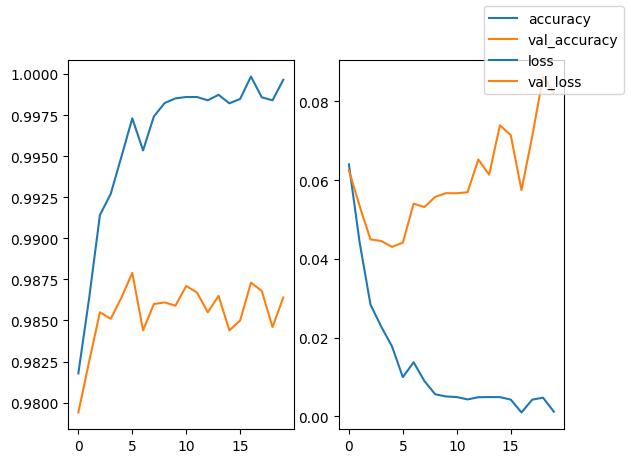

In [16]:
m = nn.Sequential(nn.Conv2d(1, 32, 3), nn.ReLU(),
                  nn.Conv2d(32, 32, 3), nn.ReLU(),
                  nn.Flatten(),
                  nn.Linear(32*24*24, 10),
)
hist = fit(m)
plot_history(hist)

# Early stopping

In [17]:
def fit2(net, train=dl_train, valid=dl_test, epochs=20,
        patience=3):
    net = net.to(device)

    optimizer = torch.optim.Adam(net.parameters())

    loss = torch.nn.CrossEntropyLoss()
    hist_loss_train = []
    hist_loss_valid = []
    hist_acc_train = []
    hist_acc_valid = []

    # Early stopping - najlepsza mozliwa dokladnosc
    best_val_acc = -float('inf')
    # early stopping - cierpliwosc
    cur_patience = patience

    for e in range(epochs):
        net.train()
        for X, y in tqdm(train):
            optimizer.zero_grad()
            X = X.to(device)
            y = y.to(device)
            pred = net(X)
            l = loss(pred, y)
            l.backward()
            optimizer.step()
        acc_train, loss_train = eval_net(net, train)
        hist_loss_train.append(loss_train)
        hist_acc_train.append(acc_train)
        if valid is not None:
            acc_valid, loss_valid = eval_net(net, valid)
            hist_loss_valid.append(loss_valid)
            hist_acc_valid.append(acc_valid)
            print("Accuracy/loss at epoch", e, ":", acc_valid, loss_valid)
            # Early stopping
            if acc_valid > best_val_acc:
                best_val_acc = acc_valid
                cur_patience = patience
            else:
                cur_patience -= 1
                if cur_patience == 0:
                    print("Early stopping at epoch", e)
                    break
    ret = {"loss": hist_loss_train, "accuracy": hist_acc_train}
    if valid is not None:
        ret["val_loss"] = hist_loss_valid
        ret["val_accuracy"] = hist_acc_valid
    return ret

  0%|          | 0/469 [00:00<?, ?it/s]

Accuracy/loss at epoch 0 : 0.9799 0.06482903901264071


  0%|          | 0/469 [00:00<?, ?it/s]

Accuracy/loss at epoch 1 : 0.9844 0.04470605558389798


  0%|          | 0/469 [00:00<?, ?it/s]

...

Accuracy/loss at epoch 7 : 0.9854 0.0538416414559586


  0%|          | 0/469 [00:00<?, ?it/s]

Accuracy/loss at epoch 8 : 0.9876 0.046167236160323956


  0%|          | 0/469 [00:00<?, ?it/s]

Accuracy/loss at epoch 9 : 0.9854 0.057586623592641266
Early stopping at epoch 9


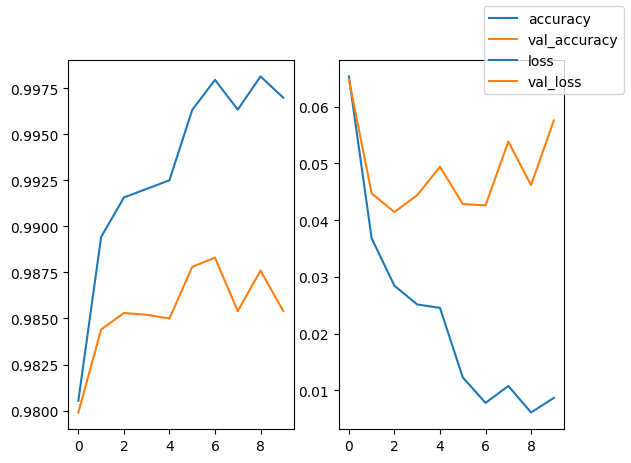

In [19]:
m = nn.Sequential(nn.Conv2d(1, 32, 3), nn.ReLU(),
                  nn.Conv2d(32, 32, 3), nn.ReLU(),
                  nn.Flatten(),
                  nn.Linear(32*24*24, 10),
)
hist = fit2(m)
plot_history(hist)

# Saving models

In [20]:
import copy

In [21]:
print(m.state_dict().keys())
print(m.state_dict()['0.weight'].shape)

odict_keys(['0.weight', '0.bias', '2.weight', '2.bias', '5.weight', '5.bias'])
torch.Size([32, 1, 3, 3])


In [24]:
# dokladnosc i strata na zbiorze testowym (oryginalnej sieci)
eval_net(m.to(device), dl_test)

(0.9854, 0.057586623592641266)

In [27]:
m.to(device)
print("Before serialization:", eval_net(m, dl_test))
torch.save(m.state_dict(), "model.pt")
# recreate model
m = nn.Sequential(nn.Conv2d(1, 32, 3), nn.ReLU(),
                  nn.Conv2d(32, 32, 3), nn.ReLU(),
                  nn.Flatten(), nn.Linear(32*24*24, 10),)
# load previous model
m.load_state_dict(torch.load("model.pt"))
m.eval() # !!!! przelaczamy w tryb ewaluacji !!!
m.to(device) # !!!! przenosimy na urzadzenie !!!
print("After serialization:", eval_net(m, dl_test))

Before serialization: (0.9854, 0.057586623592641266)
After serialization: (0.9854, 0.057586623592641266)


In [28]:
# state dict of optimizer
opt = torch.optim.SGD(m.parameters())
opt.state_dict()

{'state': {},
 'param_groups': [{'lr': 0.001,
   'momentum': 0,
   'dampening': 0,
   'weight_decay': 0,
   'nesterov': False,
   'maximize': False,
   'foreach': None,
   'differentiable': False,
   'fused': None,
   'params': [0, 1, 2, 3, 4, 5]}]}

# Learning rate scheduling

# Plot schedules

In [29]:
from torch.optim import SGD
from torch.optim import lr_scheduler

In [30]:
x = torch.tensor(0.0, requires_grad=True)

In [31]:
def plot_single_scheduler(optimizer, scheduler, name, total_steps=500):
    lrs = []
    for step in range(total_steps):
        optimizer.step()
        lrs.append(scheduler.get_last_lr())
        scheduler.step()
    plt.plot(lrs, label=name)

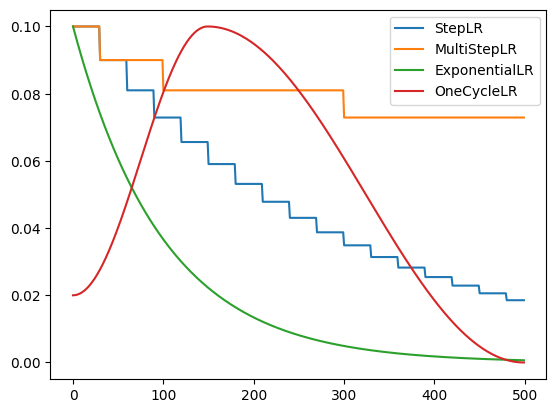

In [33]:
# Step scheduler
opt = SGD(params=[x], lr=0.1)
sched = lr_scheduler.StepLR(opt, step_size=30, gamma=0.9)
plot_single_scheduler(opt, sched, name="StepLR")
opt = SGD(params=[x], lr=0.1)
# MultiStep scheduler
opt = SGD(params=[x], lr=0.1)
sched = lr_scheduler.MultiStepLR(opt, milestones=[30, 100, 300], gamma=0.9)
plot_single_scheduler(opt, sched, name="MultiStepLR")
plt.legend()
# Exponential scheduler
opt = SGD(params=[x], lr=0.1)
sched = lr_scheduler.ExponentialLR(opt, gamma=0.99)
plot_single_scheduler(opt, sched, name="ExponentialLR")
plt.legend()
# OneCycle scheduler
opt = SGD(params=[x], lr=0.0001) # ignored, use div_factor
sched = lr_scheduler.OneCycleLR(opt, max_lr=0.1, div_factor=5, total_steps=500)
plot_single_scheduler(opt, sched, name="OneCycleLR")

plt.legend()

# ReduceLROnPlateau

In [35]:
def fit3(net, train=dl_train, valid=dl_test, epochs=50,
         patience=15,  # more patience on early stopping
         plateau_patience=3):
    net = net.to(device)

    optimizer = torch.optim.Adam(net.parameters())
    scheduler = lr_scheduler.ReduceLROnPlateau(optimizer,
                                               patience=plateau_patience,
                                               mode="max",
                                               factor=0.1)

    loss = torch.nn.CrossEntropyLoss()
    hist_loss_train = []
    hist_loss_valid = []
    hist_acc_train = []
    hist_acc_valid = []

    best_val_acc = -float('inf')
    best_model = copy.deepcopy(net.state_dict())
    cur_patience = patience

    for e in range(epochs):
        net.train()
        for X, y in tqdm(train):
            optimizer.zero_grad()
            X = X.to(device)
            y = y.to(device)
            pred = net(X)
            l = loss(pred, y)
            l.backward()
            optimizer.step()
        acc_train, loss_train = eval_net(net, train)
        hist_loss_train.append(loss_train)
        hist_acc_train.append(acc_train)
        if valid is not None:
            acc_valid, loss_valid = eval_net(net, valid)
            hist_loss_valid.append(loss_valid)
            hist_acc_valid.append(acc_valid)
            print("Accuracy/loss at epoch", e, ":", acc_valid, loss_valid)
            # Early stopping
            if acc_valid > best_val_acc:
                # remember best model
                best_model = copy.deepcopy(net.state_dict())
                # reset early stopping
                best_val_acc = acc_valid
                cur_patience = patience
            else:
                cur_patience -= 1
                if cur_patience == 0:
                    print("Early stopping at epoch", e)
                    break
        if valid is not None:
            prev_lr = scheduler.get_last_lr()
            scheduler.step(acc_valid)
            if scheduler.get_last_lr() != prev_lr:
                print("Learning rate changed to", scheduler.get_last_lr())
    ret = {"loss": hist_loss_train, "accuracy": hist_acc_train}
    if valid is not None:
        ret["val_loss"] = hist_loss_valid
        ret["val_accuracy"] = hist_acc_valid
    # restore best model
    net.load_state_dict(best_model)
    return ret

  0%|          | 0/469 [00:00<?, ?it/s]

Accuracy/loss at epoch 0 : 0.9776 0.07106710388660431


  0%|          | 0/469 [00:00<?, ?it/s]

Accuracy/loss at epoch 1 : 0.9815 0.0566037757627666


  0%|          | 0/469 [00:00<?, ?it/s]

...

Accuracy/loss at epoch 28 : 0.9893 0.05763111373764891


  0%|          | 0/469 [00:00<?, ?it/s]

Accuracy/loss at epoch 29 : 0.9893 0.057636095130254174


  0%|          | 0/469 [00:00<?, ?it/s]

Accuracy/loss at epoch 30 : 0.9893 0.057641225930121574
Early stopping at epoch 30


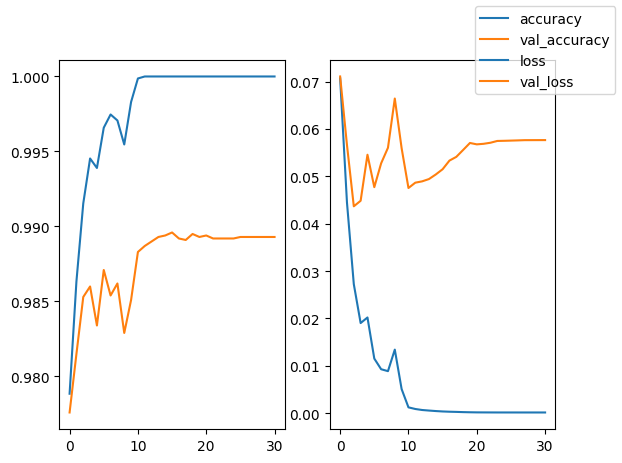

In [36]:
m = nn.Sequential(nn.Conv2d(1, 32, 3), nn.ReLU(),
                  nn.Conv2d(32, 32, 3), nn.ReLU(),
                  nn.Flatten(),
                  nn.Linear(32*24*24, 10),
)
hist = fit3(m)
plot_history(hist)